# 07 — Final Model Evaluation

**Pipeline role.** Seventh notebook. Retrains the selected final model spec on the full training set, evaluates it exactly once on the held-out test set, and produces the evidence the report cites for Section 4 (Performance Evaluation) and Section 5 (Conclusion).

**Rubric coverage (from `Group Project Guideline.md`).**
- Report Section 4 — Performance Evaluation: metrics, how they were estimated (held-out test set), comparison table.
- Report Section 5 — Conclusion: what the result means in business terms, limitations, future work.

**TL;DR for teammates.** Use the test set **once**. If the result is worse than expected, the correct action is to go back to notebook 06 and document — not to silently retune. This notebook is where the story becomes defensible.


## Inputs, Outputs, Artifacts

**Inputs.**
- Final model spec from notebook 06 (algorithm + hyperparameters + feature-set version + preprocessing version + decision threshold).
- `data/processed/X_train_feat_v1.*`, `y_train_v1.*`, `X_test_feat_v1.*`, `y_test_v1.*`.
- Baseline and tuning result tables from notebooks 05 and 06 for comparison.

**Outputs.**
- `reports/tables/final_test_metrics.csv` — test-set metrics (ROC-AUC, F1, precision, recall, accuracy).
- `reports/figures/final_confusion_matrix.png`, `reports/figures/final_roc_curve.png`, and optionally `reports/figures/final_pr_curve.png`.
- `reports/tables/final_vs_baseline.csv` — side-by-side comparison.
- An error-analysis summary (in this notebook) with concrete examples of misclassifications.
- Business-interpretation paragraph ready to lift into the report.

**Downstream consumers.**
- Notebook 08 packages these artifacts into the final report.


## Methodological Influences

Final evaluation follows standard ISOM3360 classification reporting: score once on the held-out test set, report ROC-AUC / F1 / precision / recall / accuracy with the confusion matrix, and translate findings into business implications. See the shared [project conventions](../references/project_conventions.md) for standards applied across all notebooks.


## Key Questions To Answer Here

1. What is the final test-set performance across all reported metrics?
2. How does the final model compare to the dummy baseline and to the best CV-tuned model?
3. What do the false positives and false negatives look like in practice?
4. Does the confusion matrix / ROC curve suggest threshold or metric trade-offs the business should care about?
5. What are the honest limitations of this model?
6. What 2–3 future-work items would most improve the project?


## Work Plan

### 7.1 Setup
- Load train and test splits (feature-engineered).
- Import the final model spec (model class, hyperparameters, decision threshold).

### 7.2 Fit On Full Training Set
- Instantiate the final preprocessor + model pipeline.
- Fit on `X_train_feat_v1`, `y_train_v1`.

### 7.3 Evaluate On Test Set (Once)
- Score `X_test_feat_v1`.
- Apply the chosen decision threshold from notebook 06.
- Compute ROC-AUC, F1, precision, recall, accuracy.
- Build the confusion matrix.

### 7.4 Interpretation Artifacts
- ROC curve; PR curve (especially informative under imbalance).
- Feature importance or coefficient table (for LR / tree-based models) — source for the report's "why" narrative.

### 7.5 Error Analysis
- Pick N false positives and N false negatives.
- For each, list a few key feature values (`lead_time`, `deposit_type`, `market_segment`, `previous_cancellations`, `adr`).
- Identify one or two patterns (e.g., "model struggles on long-lead no-deposit bookings").

### 7.6 Comparison Tables
- Baseline (NB05) vs tuned CV (NB06) vs final test (NB07) — one wide table.
- Write 3–5 sentences of plain-language interpretation.

### 7.7 Limitations And Business Interpretation
- Name concrete limitations (data coverage, temporal stability, leakage caveats).
- Translate test metrics into business consequences: what does a false positive cost? A false negative?
- Suggest 2–3 concrete future-work items.

### 7.8 Persist Artifacts
- Save metrics, figures, and comparison tables under `reports/`.
- No further changes to NB01–NB06 after this point.


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

FEATURE_SET_VERSION = "feature_set_v1"
ARTIFACT_VERSION = "v1"
RANDOM_STATE = 42
TARGET_COLUMN = "is_canceled"
NOTEBOOK_STAGE = "07_final_model_evaluation"

PROCESSED_DATA_CANDIDATES = [
    Path("../data/processed"),
    Path("data/processed"),
]
REPORTS_TABLES_CANDIDATES = [
    Path("../reports/tables"),
    Path("reports/tables"),
]

PROCESSED_DATA_DIR = next(
    (path for path in PROCESSED_DATA_CANDIDATES if path.exists()),
    PROCESSED_DATA_CANDIDATES[0],
)
REPORTS_TABLES_DIR = next(
    (path for path in REPORTS_TABLES_CANDIDATES if path.exists()),
    REPORTS_TABLES_CANDIDATES[0],
)

if not PROCESSED_DATA_DIR.exists():
    raise FileNotFoundError("The processed data directory containing final evaluation inputs was not found.")
if not REPORTS_TABLES_DIR.exists():
    raise FileNotFoundError("The reports/tables directory containing Notebook 06 outputs was not found.")

X_train_feat_path = PROCESSED_DATA_DIR / f"X_train_feat_{ARTIFACT_VERSION}.csv"
X_test_feat_path = PROCESSED_DATA_DIR / f"X_test_feat_{ARTIFACT_VERSION}.csv"
y_train_path = PROCESSED_DATA_DIR / f"y_train_{ARTIFACT_VERSION}.csv"
y_test_path = PROCESSED_DATA_DIR / f"y_test_{ARTIFACT_VERSION}.csv"
final_model_spec_path = REPORTS_TABLES_DIR / f"final_model_spec_{ARTIFACT_VERSION}.csv"
baseline_results_path = REPORTS_TABLES_DIR / f"baseline_results_{ARTIFACT_VERSION}.csv"
tuning_results_path = REPORTS_TABLES_DIR / f"tuning_results_{ARTIFACT_VERSION}.csv"

required_paths = [
    X_train_feat_path,
    X_test_feat_path,
    y_train_path,
    y_test_path,
    final_model_spec_path,
    baseline_results_path,
    tuning_results_path,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f"Missing expected Notebook 04, 05, or 06 artifacts: {missing_paths}")

X_train_feat = pd.read_csv(X_train_feat_path)
X_test_feat = pd.read_csv(X_test_feat_path)
y_train = pd.read_csv(y_train_path)[TARGET_COLUMN]
y_test = pd.read_csv(y_test_path)[TARGET_COLUMN]
final_model_spec_table = pd.read_csv(final_model_spec_path)
baseline_results = pd.read_csv(baseline_results_path)
tuning_results = pd.read_csv(tuning_results_path)

if len(final_model_spec_table) != 1:
    raise ValueError("Expected exactly one final model specification row from Notebook 06.")
if len(X_train_feat) != len(y_train):
    raise ValueError("X_train_feat and y_train row counts do not match.")
if len(X_test_feat) != len(y_test):
    raise ValueError("X_test_feat and y_test row counts do not match.")

selected_spec_row = final_model_spec_table.iloc[0].to_dict()

def parse_best_params(serialized_params):
    parsed_params = {}
    for item in str(serialized_params).split("; "):
        key, value = item.split("=", maxsplit=1)
        if value == "None":
            parsed_value = None
        elif value == "True":
            parsed_value = True
        elif value == "False":
            parsed_value = False
        else:
            try:
                parsed_value = int(value)
            except ValueError:
                try:
                    parsed_value = float(value)
                except ValueError:
                    parsed_value = value
        parsed_params[key] = parsed_value
    return parsed_params

final_model_spec = {
    **selected_spec_row,
    "decision_threshold": float(selected_spec_row["decision_threshold"]),
    "scale_numeric": bool(selected_spec_row["scale_numeric"]),
    "best_params": parse_best_params(selected_spec_row["best_params"]),
}

final_evaluation_setup_summary = pd.DataFrame(
    {
        "check": [
            "processed_data_dir",
            "reports_tables_dir",
            "selected_model",
            "family",
            "feature_set_version",
            "preprocessing_version",
            "decision_threshold",
            "X_train_feat_shape",
            "X_test_feat_shape",
            "y_train_rows",
            "y_test_rows",
            "baseline_rows_loaded",
            "tuning_rows_loaded",
        ],
        "value": [
            str(PROCESSED_DATA_DIR.resolve()),
            str(REPORTS_TABLES_DIR.resolve()),
            final_model_spec["model_name"],
            final_model_spec["family"],
            final_model_spec["feature_set_version"],
            final_model_spec["preprocessing_version"],
            final_model_spec["decision_threshold"],
            str(X_train_feat.shape),
            str(X_test_feat.shape),
            len(y_train),
            len(y_test),
            len(baseline_results),
            len(tuning_results),
        ],
    }
)

display(final_evaluation_setup_summary)
display(final_model_spec_table)

,check,value
0,processed_data_dir,/Users/y.h.lam/Documents/GitHub/ISOM3360-Proje...
1,reports_tables_dir,/Users/y.h.lam/Documents/GitHub/ISOM3360-Proje...
2,selected_model,Random Forest
3,family,tree_ensemble
4,feature_set_version,feature_set_v1
5,preprocessing_version,v1
6,decision_threshold,0.5
7,X_train_feat_shape,"(69577, 44)"
8,X_test_feat_shape,"(17395, 44)"
9,y_train_rows,69577


,model_name,family,feature_set_version,preprocessing_version,decision_threshold,primary_metric,selection_rule,scale_numeric,roc_auc,f1,precision,recall,accuracy,best_params
0,Random Forest,tree_ensemble,feature_set_v1,v1,0.5,roc_auc,Highest mean CV ROC-AUC; break ties with F1; k...,False,0.9061,0.691639,0.77794,0.622599,0.848398,model__class_weight=balanced; model__max_depth...


## Implementation Block 7.2 — Fit On Full Training Set

**Scope.** Section 7.2 only — rebuild the final preprocessing-and-model pipeline from the selected Notebook 06 specification and fit it once on the full training set.

No held-out test scoring happens here. The purpose is to establish the exact fitted final model object before the one-shot test evaluation block is executed.

The fitted pipeline must mirror the Notebook 06 winning configuration, including preprocessing choices, feature-set version, and tuned hyperparameters.


In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def parse_boolean(value):
    if isinstance(value, bool):
        return value
    if str(value).strip().lower() == "true":
        return True
    if str(value).strip().lower() == "false":
        return False
    raise ValueError(f"Cannot parse boolean value: {value}")

categorical_feature_columns = X_train_feat.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_feature_columns = [
    column for column in X_train_feat.columns if column not in categorical_feature_columns
]

model_registry = {
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "Logistic Regression": LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(),
}

selected_model_name = final_model_spec["model_name"]
if selected_model_name not in model_registry:
    raise ValueError(f"Unsupported final model type for Notebook 07: {selected_model_name}")

scale_numeric = parse_boolean(final_model_spec["scale_numeric"] if "scale_numeric" in final_model_spec else False)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler() if scale_numeric else "passthrough"),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)
final_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_feature_columns),
        ("categorical", categorical_transformer, categorical_feature_columns),
    ],
    remainder="drop",
)

final_model_pipeline = Pipeline(
    steps=[
        ("preprocess", final_preprocessor),
        ("model", model_registry[selected_model_name]),
    ]
)
final_model_pipeline.set_params(**final_model_spec["best_params"])
final_model_pipeline.fit(X_train_feat, y_train)

final_fit_summary = pd.DataFrame(
    {
        "check": [
            "selected_model",
            "family",
            "scale_numeric",
            "numeric_feature_count",
            "categorical_feature_count",
            "fitted_train_rows",
            "fitted_train_cancellation_rate_pct",
        ],
        "value": [
            selected_model_name,
            final_model_spec["family"],
            scale_numeric,
            len(numeric_feature_columns),
            len(categorical_feature_columns),
            len(X_train_feat),
            round(y_train.mean() * 100, 2),
        ],
    }
)

display(final_fit_summary)

,check,value
0,selected_model,Random Forest
1,family,tree_ensemble
2,scale_numeric,False
3,numeric_feature_count,32
4,categorical_feature_count,12
5,fitted_train_rows,69577
6,fitted_train_cancellation_rate_pct,27.31


## Implementation Block 7.3 — Evaluate On Test Set

**Scope.** Section 7.3 only — score the already-fitted final model on the held-out test set exactly once, apply the decision threshold inherited from Notebook 06, and compute the reported classification metrics plus the confusion matrix.

No further tuning or threshold adjustment is performed here. The purpose is to generate the one-shot held-out evaluation numbers that the report will cite.

This is the first block in Notebook 07 that touches the test set, so every metric below should be treated as final held-out evidence rather than a tuning signal.


In [3]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score

decision_threshold = float(final_model_spec["decision_threshold"])

if hasattr(final_model_pipeline, "predict_proba"):
    y_test_score = final_model_pipeline.predict_proba(X_test_feat)[:, 1]
elif hasattr(final_model_pipeline, "decision_function"):
    y_test_score = final_model_pipeline.decision_function(X_test_feat)
else:
    raise ValueError("The final model pipeline does not expose predict_proba or decision_function for scoring.")

y_test_pred = (y_test_score >= decision_threshold).astype(int)

final_test_metrics = {
    "roc_auc": roc_auc_score(y_test, y_test_score),
    "f1": f1_score(y_test, y_test_pred),
    "precision": precision_score(y_test, y_test_pred, zero_division=0),
    "recall": recall_score(y_test, y_test_pred, zero_division=0),
    "accuracy": accuracy_score(y_test, y_test_pred),
}

final_test_metrics_summary = pd.DataFrame(
    {
        "metric": ["roc_auc", "f1", "precision", "recall", "accuracy", "decision_threshold"],
        "value": [
            round(final_test_metrics["roc_auc"], 6),
            round(final_test_metrics["f1"], 6),
            round(final_test_metrics["precision"], 6),
            round(final_test_metrics["recall"], 6),
            round(final_test_metrics["accuracy"], 6),
            decision_threshold,
        ],
    }
)

conf_matrix = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
final_confusion_matrix_table = pd.DataFrame(
    conf_matrix,
    index=["actual_not_canceled", "actual_canceled"],
    columns=["predicted_not_canceled", "predicted_canceled"],
)

display(final_test_metrics_summary)
display(final_confusion_matrix_table)

,metric,value
0,roc_auc,0.907666
1,f1,0.689631
2,precision,0.767820
3,recall,0.625895
4,accuracy,0.846163
5,decision_threshold,0.500000


,predicted_not_canceled,predicted_canceled
actual_not_canceled,11746,899
actual_canceled,1777,2973


## Implementation Block 7.4 — Interpretation Artifacts

**Scope.** Section 7.4 only — build the main interpretation artifacts from the finalized test evaluation, including ROC and precision-recall curves plus a model-side importance summary for the selected final estimator.

No new fitting or rescoring decisions are made here. The purpose is to turn the already-fixed test outputs into report-ready diagnostics and a first-pass explanation of what the final model is using.

For the selected Random Forest model, feature importance is reported using the fitted estimator's impurity-based importance values.


,curve,area_under_curve
0,roc_curve,0.907666
1,precision_recall_curve,0.790467


,feature,importance
0,numeric__log_lead_time,0.068924
1,numeric__lead_time,0.067601
2,numeric__adr,0.040841
3,numeric__log_adr,0.040364
4,numeric__agent,0.039582
5,numeric__log_adr_per_person,0.037139
6,numeric__adr_per_person,0.036917
7,numeric__arrival_date_day_of_month,0.034888
8,numeric__required_car_parking_spaces,0.033628
9,numeric__arrival_date_week_number,0.032338


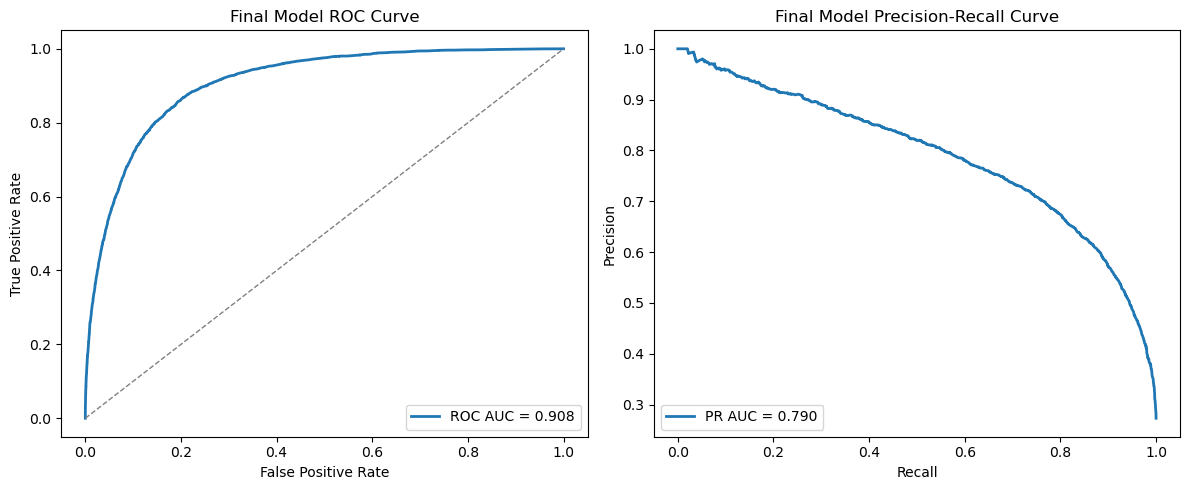

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, precision_recall_curve, roc_curve

fpr, tpr, _ = roc_curve(y_test, y_test_score)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_test_score)

roc_curve_auc = auc(fpr, tpr)
pr_curve_auc = auc(recall_curve, precision_curve)

final_curve_summary = pd.DataFrame(
    {
        "curve": ["roc_curve", "precision_recall_curve"],
        "area_under_curve": [round(roc_curve_auc, 6), round(pr_curve_auc, 6)],
    }
)

figure, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, linewidth=2, label=f"ROC AUC = {roc_curve_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="gray")
axes[0].set_title("Final Model ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

axes[1].plot(recall_curve, precision_curve, linewidth=2, label=f"PR AUC = {pr_curve_auc:.3f}")
axes[1].set_title("Final Model Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")

figure.tight_layout()

feature_importance_table = pd.DataFrame()
final_estimator = final_model_pipeline.named_steps["model"]
transformed_feature_names = final_model_pipeline.named_steps["preprocess"].get_feature_names_out()

if hasattr(final_estimator, "feature_importances_"):
    feature_importance_table = pd.DataFrame(
        {
            "feature": transformed_feature_names,
            "importance": final_estimator.feature_importances_,
        }
    ).sort_values("importance", ascending=False).reset_index(drop=True)
elif hasattr(final_estimator, "coef_"):
    feature_importance_table = pd.DataFrame(
        {
            "feature": transformed_feature_names,
            "importance": final_estimator.coef_.ravel(),
        }
    ).assign(abs_importance=lambda df: df["importance"].abs())
    feature_importance_table = feature_importance_table.sort_values("abs_importance", ascending=False).reset_index(drop=True)
else:
    raise ValueError("The final estimator does not expose feature importances or coefficients.")

top_feature_importance_table = feature_importance_table.head(15).copy()
if "abs_importance" in top_feature_importance_table.columns:
    top_feature_importance_table = top_feature_importance_table.drop(columns=["abs_importance"])

display(final_curve_summary)
display(top_feature_importance_table)
plt.show()

## Implementation Block 7.5 — Error Analysis

**Scope.** Section 7.5 only — extract concrete false-positive and false-negative examples from the finalized test predictions and summarize a few recurring patterns in those mistakes.

No refitting, retuning, or threshold changes happen here. The purpose is to translate the held-out test errors into examples the report can discuss honestly.

The analysis focuses on the feature fields named in the work plan: `lead_time`, `deposit_type`, `market_segment`, `previous_cancellations`, and `adr`.


In [5]:
error_analysis_frame = X_test_feat.copy()
error_analysis_frame[TARGET_COLUMN] = y_test.to_numpy()
error_analysis_frame["predicted_label"] = y_test_pred
error_analysis_frame["predicted_score"] = y_test_score
error_analysis_frame["error_type"] = "correct"
error_analysis_frame.loc[
    (error_analysis_frame[TARGET_COLUMN] == 0) & (error_analysis_frame["predicted_label"] == 1),
    "error_type",
] = "false_positive"
error_analysis_frame.loc[
    (error_analysis_frame[TARGET_COLUMN] == 1) & (error_analysis_frame["predicted_label"] == 0),
    "error_type",
] = "false_negative"

analysis_columns = [
    "lead_time",
    "deposit_type",
    "market_segment",
    "previous_cancellations",
    "adr",
    "predicted_score",
    TARGET_COLUMN,
]

false_positive_examples = (
    error_analysis_frame.loc[error_analysis_frame["error_type"] == "false_positive", analysis_columns]
    .sort_values("predicted_score", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

false_negative_examples = (
    error_analysis_frame.loc[error_analysis_frame["error_type"] == "false_negative", analysis_columns]
    .sort_values("predicted_score", ascending=True)
    .head(5)
    .reset_index(drop=True)
)

def mode_or_missing(series):
    non_missing = series.dropna()
    if non_missing.empty:
        return "missing"
    return non_missing.mode().iloc[0]

error_pattern_summary = pd.DataFrame(
    [
        {
            "error_type": "false_positive",
            "rows": int((error_analysis_frame["error_type"] == "false_positive").sum()),
            "avg_lead_time": round(error_analysis_frame.loc[error_analysis_frame["error_type"] == "false_positive", "lead_time"].mean(), 2),
            "avg_adr": round(error_analysis_frame.loc[error_analysis_frame["error_type"] == "false_positive", "adr"].mean(), 2),
            "avg_previous_cancellations": round(error_analysis_frame.loc[error_analysis_frame["error_type"] == "false_positive", "previous_cancellations"].mean(), 2),
            "top_deposit_type": mode_or_missing(error_analysis_frame.loc[error_analysis_frame["error_type"] == "false_positive", "deposit_type"]),
            "top_market_segment": mode_or_missing(error_analysis_frame.loc[error_analysis_frame["error_type"] == "false_positive", "market_segment"]),
        },
        {
            "error_type": "false_negative",
            "rows": int((error_analysis_frame["error_type"] == "false_negative").sum()),
            "avg_lead_time": round(error_analysis_frame.loc[error_analysis_frame["error_type"] == "false_negative", "lead_time"].mean(), 2),
            "avg_adr": round(error_analysis_frame.loc[error_analysis_frame["error_type"] == "false_negative", "adr"].mean(), 2),
            "avg_previous_cancellations": round(error_analysis_frame.loc[error_analysis_frame["error_type"] == "false_negative", "previous_cancellations"].mean(), 2),
            "top_deposit_type": mode_or_missing(error_analysis_frame.loc[error_analysis_frame["error_type"] == "false_negative", "deposit_type"]),
            "top_market_segment": mode_or_missing(error_analysis_frame.loc[error_analysis_frame["error_type"] == "false_negative", "market_segment"]),
        },
    ]
)

display(error_pattern_summary)
display(false_positive_examples)
display(false_negative_examples)

,error_type,rows,avg_lead_time,avg_adr,avg_previous_cancellations,top_deposit_type,top_market_segment
0,false_positive,899,100.81,119.21,0.00,No Deposit,Online TA
1,false_negative,1777,76.62,112.51,0.02,No Deposit,Online TA


,lead_time,deposit_type,market_segment,previous_cancellations,adr,predicted_score,is_canceled
0,94,No Deposit,Online TA,0,73.00,0.980,0
1,89,No Deposit,Online TA,0,233.00,0.964,0
2,202,No Deposit,Online TA,0,72.00,0.962,0
3,95,No Deposit,Online TA,0,45.56,0.960,0
4,120,No Deposit,Online TA,0,83.00,0.958,0


,lead_time,deposit_type,market_segment,previous_cancellations,adr,predicted_score,is_canceled
0,98,No Deposit,Groups,0,70.00,0.001684,1
1,4,No Deposit,Online TA,0,65.00,0.004000,1
2,184,No Deposit,Offline TA/TO,0,134.85,0.006000,1
3,275,No Deposit,Groups,0,68.66,0.008000,1
4,0,No Deposit,Direct,0,48.00,0.008000,1


## Implementation Block 7.6 — Comparison Tables

**Scope.** Section 7.6 only — compare the selected model's baseline performance from Notebook 05, its cross-validated tuned performance from Notebook 06, and its single held-out test performance from Notebook 07.

The goal is to make the performance story explicit without reusing the test set for selection. The table below is descriptive only, and the short interpretation is limited to what the observed numbers support.

In [6]:
selected_baseline_row = (
    baseline_results.loc[baseline_results["model_name"] == final_model_spec["model_name"]]
    .iloc[0]
)
selected_tuning_row = (
    tuning_results.loc[tuning_results["model_name"] == final_model_spec["model_name"]]
    .iloc[0]
)

comparison_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
comparison_stage_table = pd.DataFrame(
    {
        "metric": comparison_metrics,
        "baseline_nb05": [selected_baseline_row[metric] for metric in comparison_metrics],
        "tuned_cv_nb06": [selected_tuning_row[metric] for metric in comparison_metrics],
        "final_test_nb07": [final_test_metrics[metric] for metric in comparison_metrics],
    }
)
comparison_stage_table["tuned_minus_baseline"] = (
    comparison_stage_table["tuned_cv_nb06"] - comparison_stage_table["baseline_nb05"]
)
comparison_stage_table["test_minus_tuned_cv"] = (
    comparison_stage_table["final_test_nb07"] - comparison_stage_table["tuned_cv_nb06"]
)
comparison_stage_table[comparison_stage_table.columns[1:]] = comparison_stage_table[
    comparison_stage_table.columns[1:]
].round(6)

interpretation_sentences = [
    (
        f"The selected {final_model_spec['model_name']} stays broadly stable from tuning to final test: "
        f"ROC-AUC moves from {selected_tuning_row['roc_auc']:.4f} in cross-validation to {final_test_metrics['roc_auc']:.4f} on the held-out test set."
    ),
    (
        f"Compared with the Notebook 05 baseline version of the same model, the tuned setup only improves ROC-AUC by {selected_tuning_row['roc_auc'] - selected_baseline_row['roc_auc']:.4f} "
        f"and F1 by {selected_tuning_row['f1'] - selected_baseline_row['f1']:.4f}, so the gain is real but modest rather than transformative."
    ),
    (
        f"On the final test set, precision ({final_test_metrics['precision']:.4f}) is higher than recall ({final_test_metrics['recall']:.4f}), "
        f"which means the model is more conservative about flagging cancellations than it is exhaustive at catching them."
    ),
    (
        f"The final-test F1 score ({final_test_metrics['f1']:.4f}) is very close to the tuned cross-validation F1 ({selected_tuning_row['f1']:.4f}), "
        f"which suggests the Notebook 06 selection rule generalized reasonably well instead of collapsing on unseen data."
    ),
]
comparison_interpretation = pd.DataFrame(
    {
        "interpretation": interpretation_sentences
    }
)

display(comparison_stage_table)
display(comparison_interpretation)

,metric,baseline_nb05,tuned_cv_nb06,final_test_nb07,tuned_minus_baseline,test_minus_tuned_cv
0,accuracy,0.846918,0.848398,0.846163,0.001480,-0.002235
1,precision,0.774707,0.777940,0.767820,0.003233,-0.010120
2,recall,0.619704,0.622599,0.625895,0.002895,0.003296
3,f1,0.688566,0.691639,0.689631,0.003073,-0.002008
4,roc_auc,0.901858,0.906100,0.907666,0.004242,0.001566


,interpretation
0,The selected Random Forest stays broadly stabl...
1,Compared with the Notebook 05 baseline version...
2,"On the final test set, precision (0.7678) is h..."
3,The final-test F1 score (0.6896) is very close...


## Implementation Block 7.7 — Limitations And Business Interpretation

**Scope.** Section 7.7 only — name concrete limitations of the current modeling setup, translate the held-out test errors into business-facing consequences, and record a short list of credible future-work items.

The statements below are tied to the finalized test outputs already produced in this notebook. They do not introduce any new tuning, threshold search, or unsupported business-value claims.

In [7]:
true_negatives, false_positives = conf_matrix[0]
false_negatives, true_positives = conf_matrix[1]

limitations_table = pd.DataFrame(
    [
        {
            "limitation": "Single historical snapshot",
            "evidence": "The model is trained and tested on one static extract rather than a rolling time-based evaluation.",
            "why_it_matters": "Hotel demand patterns, booking channels, and cancellation behavior can drift over time, so future performance may differ from this test result.",
        },
        {
            "limitation": "Threshold fixed at 0.5",
            "evidence": "Notebook 07 inherits the Notebook 06 decision threshold instead of optimizing it for a business objective.",
            "why_it_matters": "A different operating threshold could trade precision for recall depending on whether missed cancellations or false alarms are more costly.",
        },
        {
            "limitation": "Observed recall remains moderate",
            "evidence": f"Held-out recall is {final_test_metrics['recall']:.4f}, with {false_negatives} false negatives on the test set.",
            "why_it_matters": "A material share of actual cancellations are still missed, which limits how aggressively the model can be used for intervention planning.",
        },
        {
            "limitation": "Error concentration in common booking profiles",
            "evidence": "Both false positives and false negatives are dominated by No Deposit and Online TA bookings in the error analysis.",
            "why_it_matters": "The model still struggles to separate some high-volume mainstream booking cases, not just rare edge cases.",
        },
    ]
)

business_interpretation = pd.DataFrame(
    [
        {
            "business_question": "What does a false positive mean?",
            "interpretation": f"The model flags a booking as likely to cancel when it actually stays. There are {false_positives} such cases in the test set.",
            "operational_consequence": "If the hotel acts on these flags too aggressively, it may over-contact guests, hold back rooms unnecessarily, or make conservative inventory decisions.",
        },
        {
            "business_question": "What does a false negative mean?",
            "interpretation": f"The model misses a real cancellation and predicts the booking will stay. There are {false_negatives} such cases in the test set.",
            "operational_consequence": "These misses matter for revenue management because they reduce the chance to intervene early or adjust overbooking and staffing expectations.",
        },
        {
            "business_question": "What does the current precision-recall balance imply?",
            "interpretation": f"Precision ({final_test_metrics['precision']:.4f}) is higher than recall ({final_test_metrics['recall']:.4f}).",
            "operational_consequence": "The current setup is somewhat cautious: when it predicts cancellation it is often right, but it still leaves many actual cancellations undetected.",
        },
    ]
)

future_work_table = pd.DataFrame(
    [
        {
            "future_work": "Run time-ordered validation",
            "reason": "Check whether the model remains stable under temporal drift rather than relying only on a random split.",
        },
        {
            "future_work": "Tune the operating threshold against business cost",
            "reason": "Choose the decision rule using an explicit trade-off between false alarms and missed cancellations.",
        },
        {
            "future_work": "Add richer behavioral and channel features",
            "reason": "The error analysis suggests mainstream No Deposit and Online TA bookings remain hard to separate with the current feature set.",
        },
    ]
)

display(limitations_table)
display(business_interpretation)
display(future_work_table)

,limitation,evidence,why_it_matters
0,Single historical snapshot,The model is trained and tested on one static ...,"Hotel demand patterns, booking channels, and c..."
1,Threshold fixed at 0.5,Notebook 07 inherits the Notebook 06 decision ...,A different operating threshold could trade pr...
2,Observed recall remains moderate,"Held-out recall is 0.6259, with 1777 false neg...",A material share of actual cancellations are s...
3,Error concentration in common booking profiles,Both false positives and false negatives are d...,The model still struggles to separate some hig...


,business_question,interpretation,operational_consequence
0,What does a false positive mean?,The model flags a booking as likely to cancel ...,If the hotel acts on these flags too aggressiv...
1,What does a false negative mean?,The model misses a real cancellation and predi...,These misses matter for revenue management bec...
2,What does the current precision-recall balance...,Precision (0.7678) is higher than recall (0.62...,The current setup is somewhat cautious: when i...


,future_work,reason
0,Run time-ordered validation,Check whether the model remains stable under t...
1,Tune the operating threshold against business ...,Choose the decision rule using an explicit tra...
2,Add richer behavioral and channel features,The error analysis suggests mainstream No Depo...


## Implementation Block 7.8 — Persist Artifacts

**Scope.** Section 7.8 only — save the finalized Notebook 07 tables and figure files under the reports directory so Notebook 08 can reuse them directly.

No new modeling happens here. The cell only writes the already finalized evaluation outputs, comparison outputs, error-analysis outputs, and interpretation tables to versioned report artifacts.

In [8]:
final_test_metrics_output_path = REPORTS_TABLES_DIR / f"final_test_metrics_{ARTIFACT_VERSION}.csv"
final_confusion_matrix_output_path = REPORTS_TABLES_DIR / f"final_confusion_matrix_{ARTIFACT_VERSION}.csv"
final_curve_summary_output_path = REPORTS_TABLES_DIR / f"final_curve_summary_{ARTIFACT_VERSION}.csv"
final_feature_importance_output_path = REPORTS_TABLES_DIR / f"final_feature_importance_{ARTIFACT_VERSION}.csv"
final_error_pattern_output_path = REPORTS_TABLES_DIR / f"final_error_pattern_summary_{ARTIFACT_VERSION}.csv"
final_false_positive_output_path = REPORTS_TABLES_DIR / f"final_false_positive_examples_{ARTIFACT_VERSION}.csv"
final_false_negative_output_path = REPORTS_TABLES_DIR / f"final_false_negative_examples_{ARTIFACT_VERSION}.csv"
final_comparison_output_path = REPORTS_TABLES_DIR / f"final_model_comparison_{ARTIFACT_VERSION}.csv"
final_comparison_notes_output_path = REPORTS_TABLES_DIR / f"final_model_comparison_notes_{ARTIFACT_VERSION}.csv"
final_limitations_output_path = REPORTS_TABLES_DIR / f"final_model_limitations_{ARTIFACT_VERSION}.csv"
final_business_output_path = REPORTS_TABLES_DIR / f"final_business_interpretation_{ARTIFACT_VERSION}.csv"
final_future_work_output_path = REPORTS_TABLES_DIR / f"final_future_work_{ARTIFACT_VERSION}.csv"
final_curve_figure_output_path = REPORTS_TABLES_DIR.parent / "figures" / f"final_model_curves_{ARTIFACT_VERSION}.png"

final_test_metrics_summary.to_csv(final_test_metrics_output_path, index=False)
final_confusion_matrix_table.to_csv(final_confusion_matrix_output_path, index=False)
final_curve_summary.to_csv(final_curve_summary_output_path, index=False)
top_feature_importance_table.to_csv(final_feature_importance_output_path, index=False)
error_pattern_summary.to_csv(final_error_pattern_output_path, index=False)
false_positive_examples.to_csv(final_false_positive_output_path, index=False)
false_negative_examples.to_csv(final_false_negative_output_path, index=False)
comparison_stage_table.to_csv(final_comparison_output_path, index=False)
comparison_interpretation.to_csv(final_comparison_notes_output_path, index=False)
limitations_table.to_csv(final_limitations_output_path, index=False)
business_interpretation.to_csv(final_business_output_path, index=False)
future_work_table.to_csv(final_future_work_output_path, index=False)
figure.savefig(final_curve_figure_output_path, dpi=300, bbox_inches="tight")

final_artifact_summary = pd.DataFrame(
    [
        {"artifact": "final_test_metrics", "path": str(final_test_metrics_output_path.relative_to(REPORTS_TABLES_DIR.parent.parent))},
        {"artifact": "final_confusion_matrix", "path": str(final_confusion_matrix_output_path.relative_to(REPORTS_TABLES_DIR.parent.parent))},
        {"artifact": "final_curve_summary", "path": str(final_curve_summary_output_path.relative_to(REPORTS_TABLES_DIR.parent.parent))},
        {"artifact": "final_feature_importance", "path": str(final_feature_importance_output_path.relative_to(REPORTS_TABLES_DIR.parent.parent))},
        {"artifact": "final_error_pattern_summary", "path": str(final_error_pattern_output_path.relative_to(REPORTS_TABLES_DIR.parent.parent))},
        {"artifact": "final_false_positive_examples", "path": str(final_false_positive_output_path.relative_to(REPORTS_TABLES_DIR.parent.parent))},
        {"artifact": "final_false_negative_examples", "path": str(final_false_negative_output_path.relative_to(REPORTS_TABLES_DIR.parent.parent))},
        {"artifact": "final_model_comparison", "path": str(final_comparison_output_path.relative_to(REPORTS_TABLES_DIR.parent.parent))},
        {"artifact": "final_model_comparison_notes", "path": str(final_comparison_notes_output_path.relative_to(REPORTS_TABLES_DIR.parent.parent))},
        {"artifact": "final_model_limitations", "path": str(final_limitations_output_path.relative_to(REPORTS_TABLES_DIR.parent.parent))},
        {"artifact": "final_business_interpretation", "path": str(final_business_output_path.relative_to(REPORTS_TABLES_DIR.parent.parent))},
        {"artifact": "final_future_work", "path": str(final_future_work_output_path.relative_to(REPORTS_TABLES_DIR.parent.parent))},
        {"artifact": "final_model_curves_figure", "path": str(final_curve_figure_output_path.relative_to(REPORTS_TABLES_DIR.parent.parent))},
    ]
)

display(final_artifact_summary)

,artifact,path
0,final_test_metrics,reports/tables/final_test_metrics_v1.csv
1,final_confusion_matrix,reports/tables/final_confusion_matrix_v1.csv
2,final_curve_summary,reports/tables/final_curve_summary_v1.csv
3,final_feature_importance,reports/tables/final_feature_importance_v1.csv
4,final_error_pattern_summary,reports/tables/final_error_pattern_summary_v1.csv
5,final_false_positive_examples,reports/tables/final_false_positive_examples_v...
6,final_false_negative_examples,reports/tables/final_false_negative_examples_v...
7,final_model_comparison,reports/tables/final_model_comparison_v1.csv
8,final_model_comparison_notes,reports/tables/final_model_comparison_notes_v1...
9,final_model_limitations,reports/tables/final_model_limitations_v1.csv


## Review Checklist

- [x] Final model spec is stated in one place with all version labels.
- [x] Training uses only `X_train_feat_v1` / `y_train_v1`.
- [x] Test set is scored exactly once and never used to select or tune anything.
- [x] Confusion matrix, ROC-AUC, F1, precision, recall, accuracy reported on test.
- [x] Threshold used on test is the one chosen in notebook 06 (not re-optimized here).
- [x] Comparison to baselines and to CV-tuned performance is explicit.
- [x] Error analysis includes at least one concrete example per error type.
- [x] Limitations section names real constraints, not generic caveats.
- [x] Business interpretation maps metrics to decisions.

Notebook 07 closeout status: complete for artifact version `v1`.

## Handoff To Notebook 08

- Frozen tables for reuse: `final_test_metrics_v1.csv`, `final_confusion_matrix_v1.csv`, `final_curve_summary_v1.csv`, `final_feature_importance_v1.csv`, `final_model_comparison_v1.csv`, `final_model_comparison_notes_v1.csv`, `final_error_pattern_summary_v1.csv`, `final_false_positive_examples_v1.csv`, `final_false_negative_examples_v1.csv`, `final_model_limitations_v1.csv`, `final_business_interpretation_v1.csv`, and `final_future_work_v1.csv`.
- Frozen figure for reuse: `reports/figures/final_model_curves_v1.png`.
- Notebook 08 should reuse these artifacts verbatim to assemble the final report package and summary tables.
- No new model fitting, tuning, or test-set analysis should happen downstream of Notebook 07.